In [ ]:
#!pip install matplotlib



In [1]:
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List,Literal
from helper_functions import *

import cudaq

In [9]:
def plot_results(result, num_qubits):
    # Define a dictionary of results 

    # Initialize the dictionary with all possible bit strings of length 4 for the x axis
    result_dictionary = {}

    # Generate all possible bit strings of length num_qubits
    for i in range(2**num_qubits):
        bitstr = bin(i)[2:].zfill(num_qubits)
        result_dictionary[bitstr] = 0
    
    # Update the results dictionary of results from the circuit sampling
    for k,v in result.items():
        result_dictionary[k] = v

    # Convert the dictionary to lists for x and y values
    x = list(result_dictionary.keys())
    y = list(result_dictionary.values())

    # Create the histogram
    plt.bar(x, y, color='#76B900')

    # Add title and labels
    plt.title("Sampling of the DTQW")
    plt.xlabel("Positions")
    plt.ylabel("Frequency")

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()
    


     ╭───╮╭───────────╮                ╭───────────╮               
q0 : ┤ h ├┤ ry(4.287) ├───●────●────●──┤ ry(1.105) ├──●────●────●──
     ├───┤├───────────┴╮╭─┴─╮  │    │  ├───────────┤╭─┴─╮  │    │  
q1 : ┤ h ├┤ ry(0.3382) ├┤ x ├──┼────┼──┤ ry(5.103) ├┤ x ├──┼────┼──
     ├───┤├───────────┬╯╰───╯╭─┴─╮  │  ├───────────┤╰───╯╭─┴─╮  │  
q2 : ┤ h ├┤ ry(1.385) ├──────┤ x ├──┼──┤ ry(5.802) ├─────┤ x ├──┼──
     ├───┤├───────────┤      ╰───╯╭─┴─╮├───────────┤     ╰───╯╭─┴─╮
q3 : ┤ h ├┤ ry(1.158) ├───────────┤ x ├┤ ry(1.738) ├──────────┤ x ├
     ╰───╯╰───────────╯           ╰───╯╰───────────╯          ╰───╯



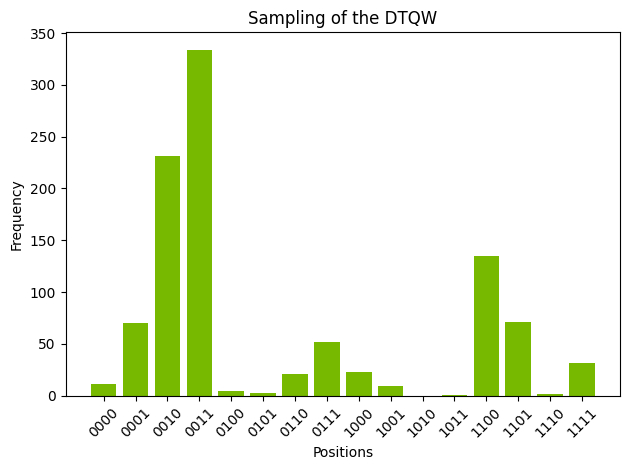

In [16]:
#test kernel
depth = 2
n_qubits = 4
seed = 123
rng = np.random.default_rng(seed)
thetas = rng.uniform(0, 2*np.pi, size=(depth*n_qubits)).astype(float)

@cudaq.kernel
def circuit(n_qubits: int, depth: int, thetas: List[float]):
    q = cudaq.qvector(n_qubits)
    # rotate
    h(q)
    for d in range(depth):
        for i in range(n_qubits):
            ry(thetas[d*n_qubits +i], q[i])

        # entangle
        for i in range(n_qubits-1):
            x.ctrl(q[0], q[i+1])


print(cudaq.draw(circuit,n_qubits, depth,thetas))
result = cudaq.sample(circuit,n_qubits, depth, thetas,shots_count=1000)
plot_results(result, n_qubits)


In [ ]:
@dataclass
class Result:
    target: str
    n_qubits: int
    depth: int
    min_time: float
    avg_time: float
    std_time: float
    ok: bool
    error: str = ""

def time_statevector(target: str, n_qubits: int, depth: int, seed: int = 0, reps: int = 5, shots: int = 1000) -> Result:
    rng = np.random.default_rng(seed)
    thetas = rng.uniform(0, 2*np.pi, size=(depth*n_qubits)).astype(float)
    cudaq.set_target(target)
    try:
        cudaq.set_target(target)
        circuit(n_qubits, depth, thetas)

        times = []
        for _ in range(reps):
            t0 = time.perf_counter()
            _ = cudaq.sample(circuit,n_qubits, depth, thetas,shots_count=shots)
            t1 = time.perf_counter()
            times.append(t1 - t0)

        return Result(target, n_qubits, depth, float(min(times)), float(np.mean(times)), float(np.std(times)), True)

    except Exception as e:
        return Result(target, n_qubits, depth, float("nan"), float("nan"),float("nan"), False, str(e))
    
def check_crossover(sweep_param : Literal["n", "d"], 
                    sweep_range : List[int],
                    const_param_val :int = 30, 
                    seed :int = 123, 
                    reps :int = 5,
                    shots :int = 1000,
                    plot :bool = True,
                    plot_std: bool = False,
                    show_df: bool = False) -> pd.DataFrame:
    rows = []
    for val in sweep_range:
        if sweep_param=="n":
            cpu = time_statevector(target="qpp-cpu", 
                                   n_qubits=val, 
                                   depth=const_param_val, 
                                   seed=seed, 
                                   reps=reps,
                                   shots=shots)
            gpu = time_statevector(target="nvidia", 
                                   n_qubits=val, 
                                   depth=const_param_val, 
                                   seed=seed, 
                                   reps=reps,
                                   shots=shots)
            print(f"{sweep_param}={val:2d} | CPU {cpu.min_time:8.4f}s {'OK' if cpu.ok else 'FAIL'} | GPU {gpu.min_time:8.4f}s {'OK' if gpu.ok else 'FAIL'}")

        elif sweep_param =="d":
            cpu = time_statevector(target="qpp-cpu", 
                                   n_qubits=const_param_val, 
                                   depth=val, 
                                   seed=seed, 
                                   reps=reps,
                                   shots=shots)
            gpu = time_statevector(target="nvidia", 
                                    n_qubits=const_param_val, 
                                    depth=val, 
                                    seed=seed, 
                                    reps=reps,
                                    shots=shots)
            print(f"{sweep_param}={val:2d} | CPU {cpu.min_time:8.4f}s {'OK' if cpu.ok else 'FAIL'} | GPU {gpu.min_time:8.4f}s {'OK' if gpu.ok else 'FAIL'}")

        rows += [cpu.__dict__, gpu.__dict__]
    df = pd.DataFrame(rows)
    if plot:
        plot_crossoverv2(df, sweep_param = sweep_param, plot_std=plot_std)
    if show_df:
        print(df)
    return pd.DataFrame(rows)



n= 1 | CPU   0.0001s OK | GPU   0.0002s OK
n= 2 | CPU   0.0002s OK | GPU   0.0002s OK
n= 3 | CPU   0.0002s OK | GPU   0.0002s OK
n= 4 | CPU   0.0003s OK | GPU   0.0003s OK
n= 5 | CPU   0.0004s OK | GPU   0.0003s OK
n= 6 | CPU   0.0004s OK | GPU   0.0003s OK
n= 7 | CPU   0.0005s OK | GPU   0.0003s OK
n= 8 | CPU   0.0005s OK | GPU   0.0004s OK
n= 9 | CPU   0.0008s OK | GPU   0.0004s OK
n=10 | CPU   0.0012s OK | GPU   0.0004s OK
n=11 | CPU   0.0018s OK | GPU   0.0005s OK
n=12 | CPU   0.0025s OK | GPU   0.0005s OK


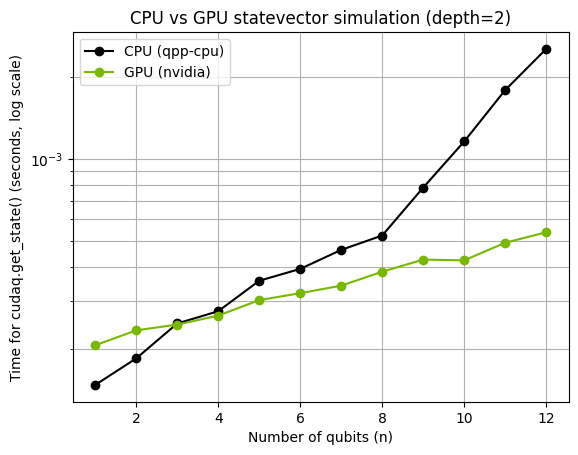

     target  n_qubits  depth  min_time  avg_time  std_time    ok error
0   qpp-cpu         1      2  0.000148  0.000202  0.000138  True      
1    nvidia         1      2  0.000207  0.000244  0.000073  True      
2   qpp-cpu         2      2  0.000185  0.000249  0.000100  True      
3    nvidia         2      2  0.000235  0.000274  0.000078  True      
4   qpp-cpu         3      2  0.000249  0.000366  0.000198  True      
5    nvidia         3      2  0.000246  0.000286  0.000070  True      
6   qpp-cpu         4      2  0.000276  0.000320  0.000082  True      
7    nvidia         4      2  0.000266  0.000299  0.000059  True      
8   qpp-cpu         5      2  0.000357  0.001791  0.002532  True      
9    nvidia         5      2  0.000303  0.000342  0.000068  True      
10  qpp-cpu         6      2  0.000395  0.001289  0.002264  True      
11   nvidia         6      2  0.000321  0.000363  0.000080  True      
12  qpp-cpu         7      2  0.000463  0.005650  0.002001  True      
13   n

In [27]:
res = check_crossover(sweep_param="n",
                      sweep_range=list(range(1, 13)), 
                      const_param_val=2, 
                      seed=123, 
                      reps=10, 
                      plot=True,
                      plot_std=False,
                      show_df=True)

d= 1 | CPU   0.0006s OK | GPU   0.0003s OK
d= 2 | CPU   0.0004s OK | GPU   0.0003s OK
d= 3 | CPU   0.0004s OK | GPU   0.0004s OK
d= 4 | CPU   0.0006s OK | GPU   0.0004s OK
d= 5 | CPU   0.0006s OK | GPU   0.0004s OK
d= 6 | CPU   0.0007s OK | GPU   0.0005s OK
d= 7 | CPU   0.0007s OK | GPU   0.0005s OK
d= 8 | CPU   0.0008s OK | GPU   0.0005s OK
d= 9 | CPU   0.0010s OK | GPU   0.0006s OK
d=10 | CPU   0.0011s OK | GPU   0.0006s OK
d=11 | CPU   0.0010s OK | GPU   0.0007s OK
d=12 | CPU   0.0011s OK | GPU   0.0007s OK
d=13 | CPU   0.0013s OK | GPU   0.0008s OK
d=14 | CPU   0.0013s OK | GPU   0.0008s OK


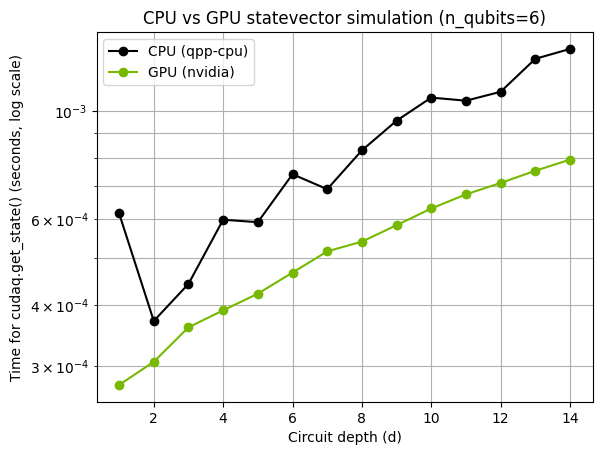

     target  n_qubits  depth  min_time  avg_time  std_time    ok error
0   qpp-cpu         6      1  0.000616  0.001623  0.001263  True      
1    nvidia         6      1  0.000275  0.000339  0.000099  True      
2   qpp-cpu         6      2  0.000371  0.004408  0.003809  True      
3    nvidia         6      2  0.000306  0.000351  0.000062  True      
4   qpp-cpu         6      3  0.000442  0.000508  0.000089  True      
5    nvidia         6      3  0.000360  0.000392  0.000048  True      
6   qpp-cpu         6      4  0.000598  0.000704  0.000094  True      
7    nvidia         6      4  0.000390  0.000431  0.000063  True      
8   qpp-cpu         6      5  0.000591  0.000639  0.000085  True      
9    nvidia         6      5  0.000422  0.000471  0.000066  True      
10  qpp-cpu         6      6  0.000741  0.001223  0.000833  True      
11   nvidia         6      6  0.000466  0.000512  0.000064  True      
12  qpp-cpu         6      7  0.000691  0.001061  0.000913  True      
13   n

In [19]:
res = check_crossover(sweep_param="d",
                      sweep_range=list(range(1, 15)), 
                      const_param_val=6, 
                      seed=123, 
                      reps=10, 
                      plot=True,
                      show_df=True)